#RNN

In [3]:
!pip install torchinfo
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.nn.utils import weight_norm
from torchinfo import summary
from tqdm import tqdm
import glob

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##First
Gather data by source and movement type

In [4]:
# Directory containing the .txt files
directory = '/content/drive/MyDrive/Colab Notebooks/wisdm-dataset/raw/phone/accel'

# Specify the expected column format
column_names = ['ID', 'activity', 'timestamp', 'ph_x_ac', 'ph_y_ac', 'ph_z_ac']

# List to store all the data from each file
all_data = []

files = glob.glob(directory + '/*.txt')

# Recursively search through the directory and subdirectories for .txt files
phone_accel = pd.DataFrame()
for file in files:
    # Read the CSV file into a dataframe
    df = pd.read_csv(file, header=None, names=column_names)

    # Join the dataframe with the combined_df on the specified column
    if phone_accel.empty:
        phone_accel = df
    else:
        phone_accel = pd.merge(phone_accel, df, on='timestamp')

phone_accel = phone_accel.drop_duplicates(subset='timestamp', keep="last")
# Combine all the data into one DataFrame
# phone_accel = pd.concat(all_data, axis=1, keys='timestamp')

# Save the combined data into a single CSV file
output_csv = 'phone_accel.csv'
phone_accel.to_csv(output_csv, index=False)
phone_accel['ph_z_ac'] = pd.to_numeric(phone_accel['ph_z_ac'].str.replace(';', ''), errors='coerce')

# Show the first few rows of the aggregated data
print(f"Combined data saved to {output_csv}")
print(phone_accel.head())

Combined data saved to phone_accel.csv
     ID activity         timestamp    ph_x_ac   ph_y_ac   ph_z_ac
0  1638        A  1140276360239317  12.161048 -3.772963  0.129736
1  1638        A  1140276409739317  13.959094 -2.982876 -0.193481
2  1638        A  1140276459239317  14.770728 -5.254973  3.917363
3  1638        A  1140276508739317  14.902410 -5.231031  4.300435
4  1638        A  1140276558239317  13.209708 -5.922955  2.806453


In [5]:
# Directory containing the .txt files
directory = '/content/drive/MyDrive/Colab Notebooks/wisdm-dataset/raw/phone/gyro'

# Specify the expected column format
column_names = ['ID', 'activity', 'timestamp', 'ph_x_gy', 'ph_y_gy', 'ph_z_gy']

# List to store all the data from each file
all_data = []

files = glob.glob(directory + '/*.txt')

# Recursively search through the directory and subdirectories for .txt files
phone_gyro = pd.DataFrame()
for file in files:
    # Read the CSV file into a dataframe
    df = pd.read_csv(file, header=None, names=column_names)

    # Join the dataframe with the combined_df on the specified column
    if phone_gyro.empty:
        phone_gyro = df
    else:
        phone_gyro = pd.merge(phone_gyro, df, on='timestamp')

phone_gyro = phone_gyro.drop_duplicates(subset='timestamp', keep="last")
# Combine all the data into one DataFrame
# phone_gyro = pd.concat(all_data, axis=1, keys='timestamp')

# Save the combined data into a single CSV file
output_csv = 'phone_gyro.csv'
phone_gyro.to_csv(output_csv, index=False)
phone_gyro['ph_z_gy'] = pd.to_numeric(phone_gyro['ph_z_gy'].str.replace(';', ''), errors='coerce')

# Show the first few rows of the aggregated data
print(f"Combined data saved to {output_csv}")
print(phone_gyro.head())

Combined data saved to phone_gyro.csv
     ID activity         timestamp   ph_x_gy   ph_y_gy   ph_z_gy
0  1641        A  1217641979919000  1.393366 -0.789361  0.049002
1  1641        A  1217642020229000  1.390170 -0.601874  0.051133
2  1641        A  1217642060543000  1.306014  0.383495  0.133158
3  1641        A  1217642100772000  0.818123  0.661529  0.258859
4  1641        A  1217642141055000  0.110787 -0.170442  0.219444


In [6]:
import glob
# Directory containing the .txt files
directory = '/content/drive/MyDrive/Colab Notebooks/wisdm-dataset/raw/watch/accel'

# Specify the expected column format
column_names = ['ID', 'activity', 'timestamp', 'wa_x_ac', 'wa_y_ac', 'wa_z_ac']

# List to store all the data from each file
all_data = []

files = glob.glob(directory + '/*.txt')

# Recursively search through the directory and subdirectories for .txt files
watch_accel = pd.DataFrame()
for file in files:
    # Read the CSV file into a dataframe
    df = pd.read_csv(file, header=None, names=column_names)

    # Join the dataframe with the combined_df on the specified column
    if watch_accel.empty:
        watch_accel = df
    else:
        watch_accel = pd.merge(watch_accel, df, on='timestamp')

watch_accel = watch_accel.drop_duplicates(subset='timestamp', keep="last")
# Combine all the data into one DataFrame
# watch_accel = pd.concat(all_data, axis=1, keys='timestamp')

# Save the combined data into a single CSV file
output_csv = 'watch_accel.csv'
watch_accel.to_csv(output_csv, index=False)
watch_accel['wa_z_ac'] = pd.to_numeric(watch_accel['wa_z_ac'].str.replace(';', ''), errors='coerce')

# Show the first few rows of the aggregated data
print(f"Combined data saved to {output_csv}")
print(watch_accel.head())

Combined data saved to watch_accel.csv
     ID activity         timestamp   wa_x_ac   wa_y_ac   wa_z_ac
0  1646        A  1470028569293284  9.859023  1.469142  3.279009
1  1646        A  1470028618793284  6.966828 -1.650503 -0.908450
2  1646        A  1470028668293284  5.168782 -4.312855 -6.005705
3  1646        A  1470028717793284  2.812888 -4.080617 -7.698406
4  1646        A  1470028767293284  1.536778 -5.292084 -9.225906


In [7]:
import glob
# Directory containing the .txt files
directory = '/content/drive/MyDrive/Colab Notebooks/wisdm-dataset/raw/watch/gyro'

# Specify the expected column format
column_names = ['ID', 'activity', 'timestamp', 'wa_x_gy', 'wa_y_gy', 'wa_z_gy']

# List to store all the data from each file
all_data = []

files = glob.glob(directory + '/*.txt')

# Recursively search through the directory and subdirectories for .txt files
watch_gyro = pd.DataFrame()
for file in files:
    # Read the CSV file into a dataframe
    df = pd.read_csv(file, header=None, names=column_names)

    # Join the dataframe with the combined_df on the specified column
    if watch_gyro.empty:
        watch_gyro = df
    else:
        watch_gyro = pd.merge(watch_gyro, df, on='timestamp')

watch_gyro = watch_gyro.drop_duplicates(subset='timestamp', keep="last")
# Combine all the data into one DataFrame
# watch_gyro = pd.concat(all_data, axis=1, keys='timestamp')

# Save the combined data into a single CSV file
output_csv = 'watch_gyro.csv'
watch_gyro.to_csv(output_csv, index=False)
watch_gyro['wa_z_gy'] = pd.to_numeric(watch_gyro['wa_z_gy'].str.replace(';', ''), errors='coerce')

# Show the first few rows of the aggregated data
print(f"Combined data saved to {output_csv}")
print(watch_gyro.head())

Combined data saved to watch_gyro.csv
     ID activity         timestamp   wa_x_gy   wa_y_gy   wa_z_gy
0  1649        A  2723190229338443  0.092216 -0.452995  4.077074
1  1649        A  2723190278838443  1.213939 -0.932364  3.682926
2  1649        A  2723190328338443  2.565760 -0.766183  2.896761
3  1649        A  2723190377838443  2.300509 -0.416776  1.890086
4  1649        A  2723190427338443  0.805943 -0.095066  0.691663


<ipython-input-7-231447bfffdd>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  watch_gyro['wa_z_gy'] = pd.to_numeric(watch_gyro['wa_z_gy'].str.replace(';', ''), errors='coerce')


In [8]:
#ensure proper ordering
phone_accel = phone_accel.sort_values(by=['ID','timestamp'])
phone_gyro = phone_gyro.sort_values(by=['ID','timestamp'])
watch_accel = watch_accel.sort_values(by=['ID','timestamp'])
watch_gyro = watch_gyro.sort_values(by=['ID','timestamp'])

##Second
Merge the gathered data by movement type and fill any missing values with previous (or next) values

In [9]:
total_accel  = pd.merge(
    left=phone_accel,
    right=watch_accel,
    how='outer',
    left_on=['ID', 'timestamp', 'activity'],
    right_on=['ID', 'timestamp', 'activity'],
)

total_gyro  = pd.merge(
    left=phone_gyro,
    right=watch_gyro,
    how='outer',
    left_on=['ID', 'timestamp', 'activity'],
    right_on=['ID', 'timestamp', 'activity'],
)

#really make sure of proper ordering
total_accel = total_accel.sort_values(by=['ID','timestamp', 'activity'])
total_gyro = total_gyro.sort_values(by=['ID','timestamp','activity'])

In [10]:
#fill na with previous value (or next if needed.)
total_accel = total_accel.ffill()
total_accel = total_accel.bfill()
total_gyro = total_gyro.ffill()
total_gyro = total_gyro.bfill()

##Third
Now merge all data together.

In [11]:
total_data = pd.merge(
    left=total_accel,
    right=total_gyro,
    how='outer',
    left_on=['ID', 'timestamp', 'activity'],
    right_on=['ID', 'timestamp', 'activity'],
)

total_data = total_data.sort_values(by=['ID','timestamp', 'activity'])
total_data = total_data.ffill()
total_data = total_data.bfill()

##Fourth
Create a 10 sec time interval and then create aggregates for mean and std dev over these time intervals.

In [12]:
# Convert timestamp to a 10-second interval
total_accel['time_interval'] = (total_accel['timestamp'] // 200_000_000) * 1  # Each 10-second interval

# Group by ID, activity, and the 10-second interval, then calculate mean for x, y, z
df_aggregated1 = total_accel.groupby(['ID', 'activity', 'time_interval']).agg({ # swap between accel, gyro, or all here.
    'ph_x_ac': 'mean',
    'ph_y_ac': 'mean',
    'ph_z_ac': 'mean',
    'wa_x_ac': 'mean',
    'wa_y_ac': 'mean',
    'wa_z_ac': 'mean',
    # 'ph_x_gy': 'mean',
    # 'ph_y_gy': 'mean',
    # 'ph_z_gy': 'mean',
    # 'wa_x_gy': 'mean',
    # 'wa_y_gy': 'mean',
    # 'wa_z_gy': 'mean',
}).reset_index()

#If we don't seperate mean and std dev here, we'll need to do it later.
df_aggregated2 = total_accel.groupby(['ID', 'activity', 'time_interval']).agg({ # swap between accel, gyro, or all here.
    'ph_x_ac': 'std',
    'ph_y_ac': 'std',
    'ph_z_ac': 'std',
    'wa_x_ac': 'std',
    'wa_y_ac': 'std',
    'wa_z_ac': 'std'#,
    # 'ph_x_gy': 'std',
    # 'ph_y_gy': 'std',
    # 'ph_z_gy': 'std',
    # 'wa_x_gy': 'std',
    # 'wa_y_gy': 'std',
    # 'wa_z_gy': 'std'
}).reset_index()

,ID,activity,time_interval,ph_x_ac,ph_y_ac,ph_z_ac,wa_x_ac,wa_y_ac,wa_z_ac
0,1638,A,5701381,NaN,NaN,NaN,NaN,NaN,NaN
1,1638,A,5701382,0.786847,1.284076,2.035247,0.000000,0.000000,0.000000
2,1638,A,5701383,2.057349,1.718520,0.590562,0.000000,0.000000,0.000000
3,1638,A,5701384,2.971456,1.091550,0.706665,0.000000,0.000000,0.000000
4,1638,A,5701385,0.884902,1.764227,1.164643,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
32409,1646,S,7344419,0.000000,0.000000,0.000000,1.321749,0.278157,1.654990
32410,1646,S,7344420,0.000000,0.000000,0.000000,1.242079,1.574923,1.296830
32411,1646,S,7344421,0.000000,0.000000,0.000000,1.299502,1.455397,2.555498
32412,1646,S,7344422,0.000000,0.000000,0.000000,0.655284,0.567147,1.038680


##Fifth
Merge the aggregate data into the main df.

In [13]:
test = pd.merge(
    left=total_accel, # swap between accel, gyro, or all here.
    right=df_aggregated1,
    how='outer',
    left_on=['ID', 'time_interval', 'activity'],
    right_on=['ID', 'time_interval', 'activity'],
    suffixes=('', '_avg')
)
test = pd.merge(
    left=test,
    right=df_aggregated2,
    how='outer',
    left_on=['ID', 'time_interval', 'activity'],
    right_on=['ID', 'time_interval', 'activity'],
    suffixes=('', '_std')
)

test.ffill(inplace=True)
test.bfill(inplace=True)
test

,ID,activity,timestamp,ph_x_ac,ph_y_ac,ph_z_ac,wa_x_ac,wa_y_ac,wa_z_ac,time_interval,...,ph_z_ac_avg,wa_x_ac_avg,wa_y_ac_avg,wa_z_ac_avg,ph_x_ac_std,ph_y_ac_std,ph_z_ac_std,wa_x_ac_std,wa_y_ac_std,wa_z_ac_std
0,1638,D,1136064766273803,5.376629,-5.809530,2.799720,2.764255,-10.093954,2.384774,5680323,...,2.799720,2.764255,-10.093954,2.384774,0.64193,4.269553,2.489796,0.000000,0.000000,0.000000
1,1638,D,1136064815773803,4.653580,-4.550180,1.224335,2.764255,-10.093954,2.384774,5680324,...,-1.141136,2.764255,-10.093954,2.384774,0.64193,4.269553,2.489796,0.000000,0.000000,0.000000
2,1638,D,1136064865273803,3.458873,-3.137601,0.410306,2.764255,-10.093954,2.384774,5680324,...,-1.141136,2.764255,-10.093954,2.384774,0.64193,4.269553,2.489796,0.000000,0.000000,0.000000
3,1638,D,1136064914773803,4.093337,-6.934805,-4.308665,2.764255,-10.093954,2.384774,5680324,...,-1.141136,2.764255,-10.093954,2.384774,0.64193,4.269553,2.489796,0.000000,0.000000,0.000000
4,1638,D,1136064964273803,4.902577,-12.817359,-1.890521,2.764255,-10.093954,2.384774,5680324,...,-1.141136,2.764255,-10.093954,2.384774,0.64193,4.269553,2.489796,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129633,1646,B,1470410903169314,0.836474,3.524564,9.426421,19.557337,-19.827282,7.473650,7352054,...,9.426421,8.783130,-19.827282,7.950695,0.00000,0.000000,0.000000,12.772743,0.000000,4.720013
129634,1646,B,1470410953151984,0.836474,3.524564,9.426421,19.557337,-19.827282,2.354847,7352054,...,9.426421,8.783130,-19.827282,7.950695,0.00000,0.000000,0.000000,12.772743,0.000000,4.720013
129635,1646,B,1470411003134654,0.836474,3.524564,9.426421,19.557337,-17.289429,-0.530166,7352055,...,9.426421,19.557337,-6.185121,-2.539699,0.00000,0.000000,0.000000,0.000000,10.725794,3.734310
129636,1646,B,1470411053117324,0.836474,3.524564,9.426421,19.557337,-5.383063,-6.848465,7352055,...,9.426421,19.557337,-6.185121,-2.539699,0.00000,0.000000,0.000000,0.000000,10.725794,3.734310


##Sixth
Prep data by splitting into predictors and target. Then into testing and training.

In [14]:
#Split into predictors an target.
X = test.drop(['ID', 'activity', 'time_interval', 'timestamp'], axis=1)
y = test['activity']

#need to convert the letters into numbers
y = [ord(x) - 64 for x in y]
for i in range(len(y)): #because the data skips a letter, we have to compensate for that
    if y[i] > 13:       #by shifting some down 1
      y[i] = y[i]-2
    else:
      y[i] = y[i]-1
np.unique(y)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17])

In [15]:
#Torch data prep here
all_sequences = X.to_numpy()
all_labels = np.array(y)

# Train-Validation-Test Split
X_train, X_temp, y_train, y_temp = train_test_split(all_sequences, all_labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Convert to PyTorch tensors
X_train, X_val, X_test = (
    torch.from_numpy(X_train).float(),
    torch.from_numpy(X_val).float(),
    torch.from_numpy(X_test).float(),
)
y_train, y_val, y_test = (
    torch.from_numpy(y_train).long(),
    torch.from_numpy(y_val).long(),
    torch.from_numpy(y_test).long(),
)

# Debugging outputs to verify the data
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: torch.Size([90746, 18]), y_train shape: torch.Size([90746])
X_val shape: torch.Size([19446, 18]), y_val shape: torch.Size([19446])
X_test shape: torch.Size([19446, 18]), y_test shape: torch.Size([19446])


##Seventh
Run the model and evaluate performance.

Epoch 1, Train Loss: 1.2879, Val Loss: 1.0375


Epoch 2, Train Loss: 0.9943, Val Loss: 0.9556


Epoch 3, Train Loss: 0.9268, Val Loss: 0.9038


Epoch 4, Train Loss: 0.8859, Val Loss: 0.8855


Epoch 5, Train Loss: 0.8534, Val Loss: 0.8569


...

Epoch 56, Train Loss: 0.4129, Val Loss: 0.5134


Epoch 57, Train Loss: 0.4107, Val Loss: 0.5155


Epoch 58, Train Loss: 0.4078, Val Loss: 0.5089


Epoch 59, Train Loss: 0.4033, Val Loss: 0.5135


Epoch 60, Train Loss: 0.4010, Val Loss: 0.5008


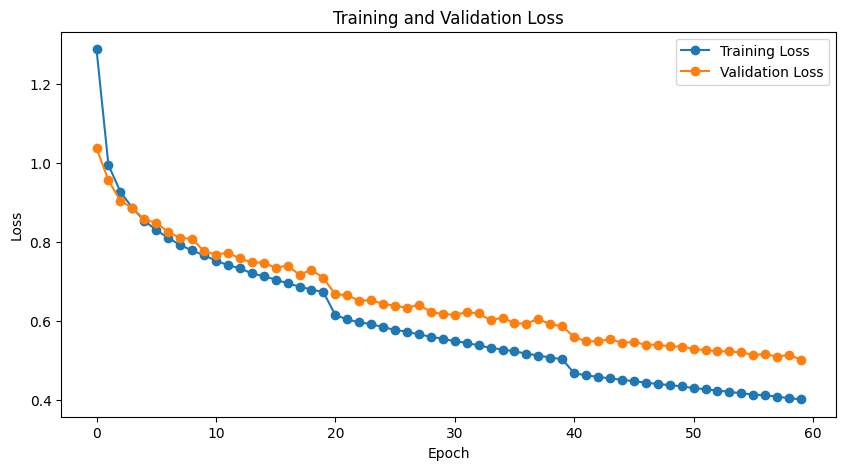

Test Accuracy: 81.98%


In [16]:
class RNN(nn.Module):
    def __init__(self, input_size, num_classes, hidden_size=64, num_layers=6):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Initialize hidden state with zeros
        # Correction: Include batch size in h0 initialization
        batch_size = x.size(0)  # Get batch size from input
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        # Reshape x to (batch_size, sequence_length, input_size)
        # if it is not already in this format.
        if x.dim() == 2:  # If x is 2D, add a sequence length dimension of 1
            x = x.unsqueeze(1)
        out, _ = self.rnn(x, h0)
        out = out[:, -1, :]
        out = self.fc(out)

        return out

# Model Initialization
input_dim = len(X.columns)  # Number of features: x, y, z
output_dim = len(np.unique(df['activity']))  # Number of classes
model = RNN(input_size=input_dim, num_classes=output_dim)

# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Training Parameters
epochs = 60
batch_size = 32

# DataLoader Preparation
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training Loop
train_losses = []
val_losses = []

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training", unit="batch", leave=False)

    for batch_x, batch_y in progress_bar:
        optimizer.zero_grad()
        outputs = model(batch_x.float())
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        avg_loss = running_train_loss / (progress_bar.n + 1)
        progress_bar.set_postfix(loss=avg_loss)

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x.float())
            val_loss = criterion(outputs, batch_y)
            running_val_loss += val_loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step()
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Testing Phase
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x.float())
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 81.98%

CR by library method=
               precision    recall  f1-score   support

           0       0.65      0.64      0.65      1123
           1       0.82      0.89      0.85      1032
           2       0.67      0.64      0.65      1067
           3       0.98      0.93      0.96      1080
           4       0.95      0.95      0.95      1057
           5       0.94      0.97      0.96      1114
           6       0.88      0.94      0.91      1102
           7       0.74      0.78      0.76      1050
           8       0.77      0.72      0.75      1125
           9       0.86      0.82      0.84      1097
          10       0.93      0.93      0.93      1116
          11       0.77      0.70      0.73      1095
          12       0.66      0.68      0.67      1045
          13       0.75      0.70      0.72      1066
          14       0.88      0.86      0.87      1110
          15       0.92      0.95      0.94      1044
          16       0.86      0.91  

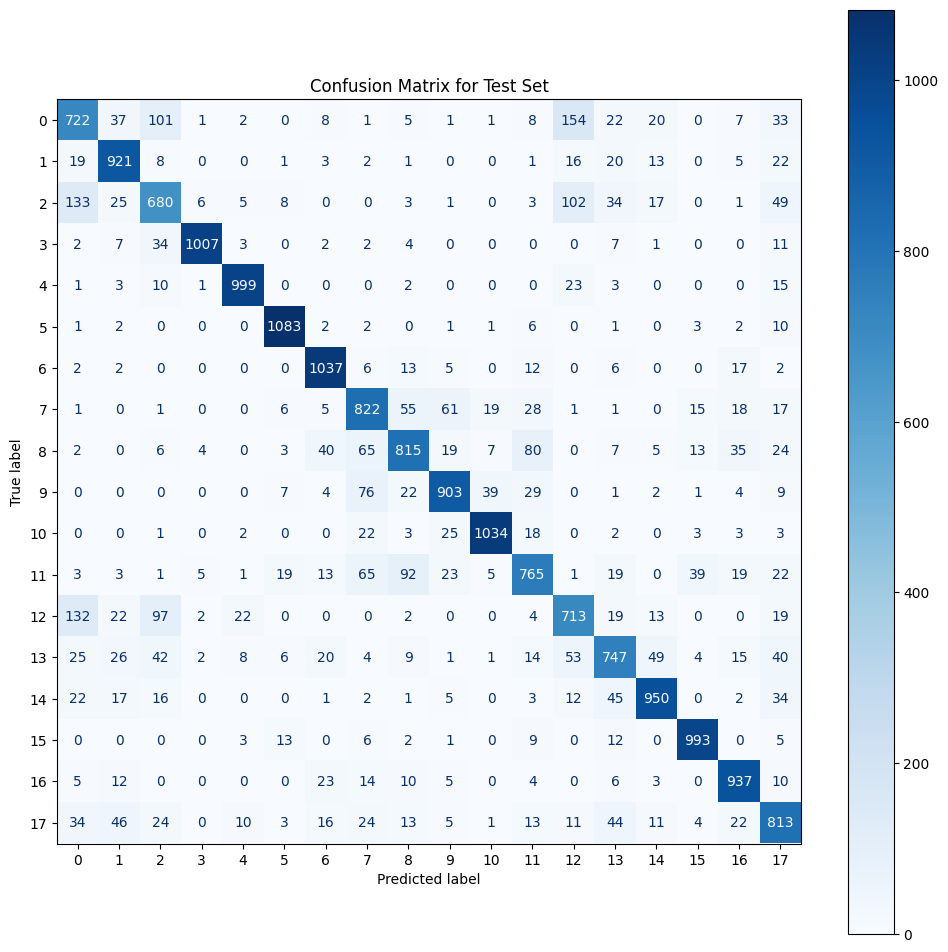

In [19]:
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            outputs = model(batch_x.float())
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    return all_labels, all_preds

# Get predictions and labels
y_true, y_pred = evaluate_model(model, test_loader)

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("\nCR by library method=\n", classification_report(y_true, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=np.unique(y))
fig, ax = plt.subplots(figsize=(12,12))
disp.plot(ax=ax,cmap='Blues', values_format='.0f')
plt.title("Confusion Matrix for Test Set")
plt.show()

Hyperparameter notes: \\
  Learning rate caused oscillations at 1e-2 and gave worse results at 1e-4. \\
  Layers/# of nodes, not guarenteed that this is optimal, but doubling or halving either number from current gave worse results. \\

Best improvement to results came from cleaning up data. Merging all the data together by time stamp gave ok results. Adding the average over 10s intervals improved results. Adding the std dev over 10s further improved results.

Also, acceleration measurements only gave better results than gyro only and combined.